# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [1]:
#!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

In [2]:
#!rm SUSY.csv

In [3]:
#!gunzip SUSY.csv.gz

In [4]:
ls -lh

total 2.5G
-rw-r--r-- 1 zendevs zendevs  33K Mar 20 23:27 Blackjack.py
-rw-r--r-- 1 zendevs zendevs  921 Feb  4 00:38 HelloWorld.ipynb
-rw-r--r-- 1 zendevs zendevs 287K Feb  9 21:26 Lab.2.ipynb
-rw-r--r-- 1 zendevs zendevs  62K Feb 15 19:27 Lab.3.ipynb
-rw-r--r-- 1 zendevs zendevs  56K Feb 15 18:26 Lab.3Solutions.ipynb
-rw-r--r-- 1 zendevs zendevs 103K Feb 21 03:07 Lab.4.Solution.ipynb
-rw-r--r-- 1 zendevs zendevs  32K Feb 20 23:58 Lab.4.ipynb
-rw-r--r-- 1 zendevs zendevs  64K Feb 27 22:11 Lab.5.Solutions.ipynb
-rw-r--r-- 1 zendevs zendevs  64K Feb 27 22:08 Lab.5.ipynb
-rw-r--r-- 1 zendevs zendevs 392K Mar 20 23:28 Lab.6.Solution.ipynb
-rw-r--r-- 1 zendevs zendevs 363K Mar 20 22:55 Lab.6.ipynb
-rw-r--r-- 1 zendevs zendevs 918K Mar 27 20:12 Lab.7.ipynb
-rw-r--r-- 1 zendevs zendevs 200K Mar 20 19:23 Lab_6_complete.ipynb
-rw-r--r-- 1 zendevs zendevs 299K Mar  6 17:37 Lecture.11.ipynb
-rw-r--r-- 1 zendevs zendevs 117K Mar  6 17:37 Lecture.12.ipynb
-rw-r--r-- 1 zendevs zendevs 124K Feb 20 2

The data is provided as a comma separated file.

The above file directory is my standard python work env, SUSY.csv was downloaded correctly and is quite hefty at ~2.3G

In [5]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [6]:
!ls -lh

total 2.5G
-rw-r--r-- 1 zendevs zendevs  33K Mar 20 23:27 Blackjack.py
-rw-r--r-- 1 zendevs zendevs  921 Feb  4 00:38 HelloWorld.ipynb
-rw-r--r-- 1 zendevs zendevs 287K Feb  9 21:26 Lab.2.ipynb
-rw-r--r-- 1 zendevs zendevs  62K Feb 15 19:27 Lab.3.ipynb
-rw-r--r-- 1 zendevs zendevs  56K Feb 15 18:26 Lab.3Solutions.ipynb
-rw-r--r-- 1 zendevs zendevs 103K Feb 21 03:07 Lab.4.Solution.ipynb
-rw-r--r-- 1 zendevs zendevs  32K Feb 20 23:58 Lab.4.ipynb
-rw-r--r-- 1 zendevs zendevs  64K Feb 27 22:11 Lab.5.Solutions.ipynb
-rw-r--r-- 1 zendevs zendevs  64K Feb 27 22:08 Lab.5.ipynb
-rw-r--r-- 1 zendevs zendevs 392K Mar 20 23:28 Lab.6.Solution.ipynb
-rw-r--r-- 1 zendevs zendevs 363K Mar 20 22:55 Lab.6.ipynb
-rw-r--r-- 1 zendevs zendevs 918K Mar 27 20:12 Lab.7.ipynb
-rw-r--r-- 1 zendevs zendevs 200K Mar 20 19:23 Lab_6_complete.ipynb
-rw-r--r-- 1 zendevs zendevs 299K Mar  6 17:37 Lecture.11.ipynb
-rw-r--r-- 1 zendevs zendevs 117K Mar  6 17:37 Lecture.12.ipynb
-rw-r--r-- 1 zendevs zendevs 124K Feb 20 2

We see that we have 5 million datapoints.

As noted before, SUSY stands at around 2.3 Gigabytes

In [7]:
!wc -l SUSY.csv

5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [8]:
!head -500000 SUSY.csv > SUSY-small.csv

In [9]:
ls -lh

total 2.5G
-rw-r--r-- 1 zendevs zendevs  33K Mar 20 23:27 Blackjack.py
-rw-r--r-- 1 zendevs zendevs  921 Feb  4 00:38 HelloWorld.ipynb
-rw-r--r-- 1 zendevs zendevs 287K Feb  9 21:26 Lab.2.ipynb
-rw-r--r-- 1 zendevs zendevs  62K Feb 15 19:27 Lab.3.ipynb
-rw-r--r-- 1 zendevs zendevs  56K Feb 15 18:26 Lab.3Solutions.ipynb
-rw-r--r-- 1 zendevs zendevs 103K Feb 21 03:07 Lab.4.Solution.ipynb
-rw-r--r-- 1 zendevs zendevs  32K Feb 20 23:58 Lab.4.ipynb
-rw-r--r-- 1 zendevs zendevs  64K Feb 27 22:11 Lab.5.Solutions.ipynb
-rw-r--r-- 1 zendevs zendevs  64K Feb 27 22:08 Lab.5.ipynb
-rw-r--r-- 1 zendevs zendevs 392K Mar 20 23:28 Lab.6.Solution.ipynb
-rw-r--r-- 1 zendevs zendevs 363K Mar 20 22:55 Lab.6.ipynb
-rw-r--r-- 1 zendevs zendevs 918K Mar 27 20:12 Lab.7.ipynb
-rw-r--r-- 1 zendevs zendevs 200K Mar 20 19:23 Lab_6_complete.ipynb
-rw-r--r-- 1 zendevs zendevs 299K Mar  6 17:37 Lecture.11.ipynb
-rw-r--r-- 1 zendevs zendevs 117K Mar  6 17:37 Lecture.12.ipynb
-rw-r--r-- 1 zendevs zendevs 124K Feb 20 2

Though cluttered, you can observe the SUSY-small.csv file has been created above pycahce

In [10]:
! wc -l SUSY-small.csv

500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [11]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [12]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [13]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [14]:
FeatureNames

['M_R',
 'R',
 'M_Delta_R',
 'MT2',
 'MET_rel',
 'axial_MET',
 'cos_theta_r1',
 'S_R',
 'M_TR_2',
 'dPhi_r_b']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [16]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [17]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [18]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


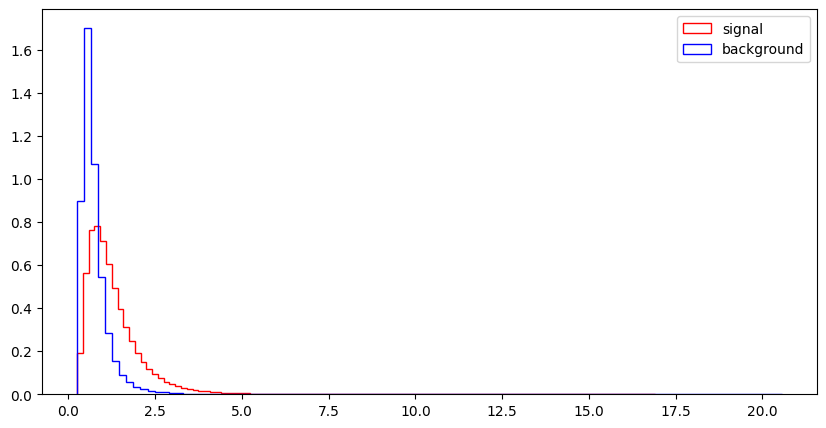

l_1_eta


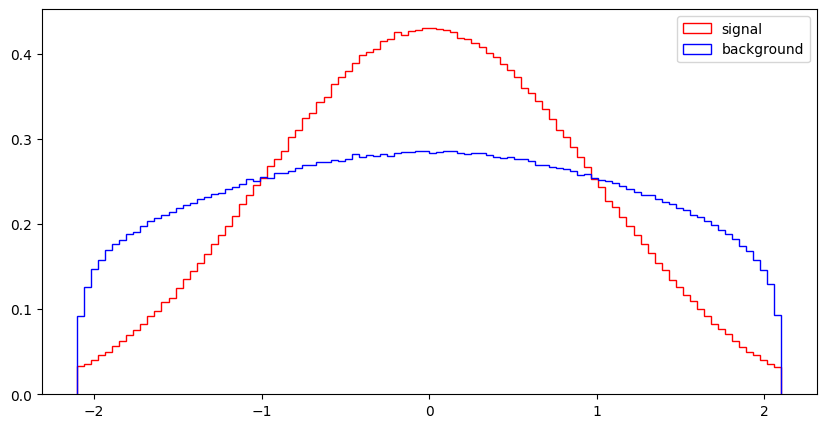

l_1_phi


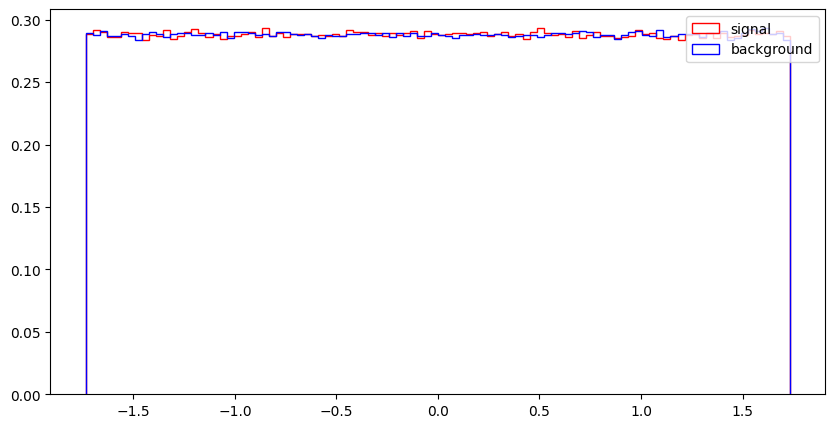

l_2_pT


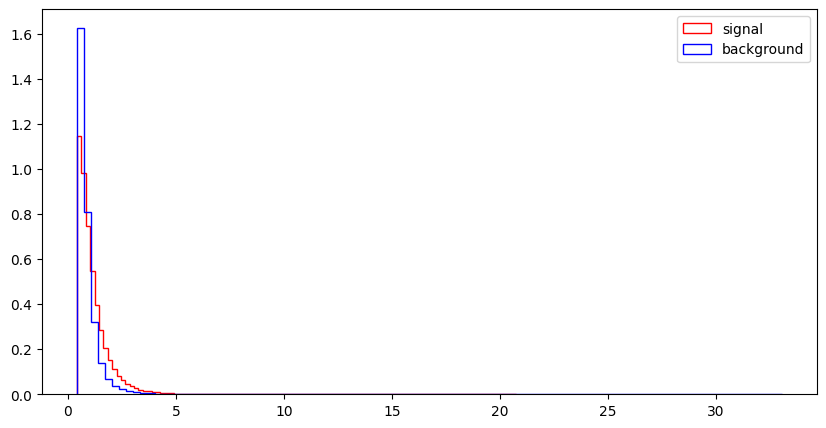

l_2_eta


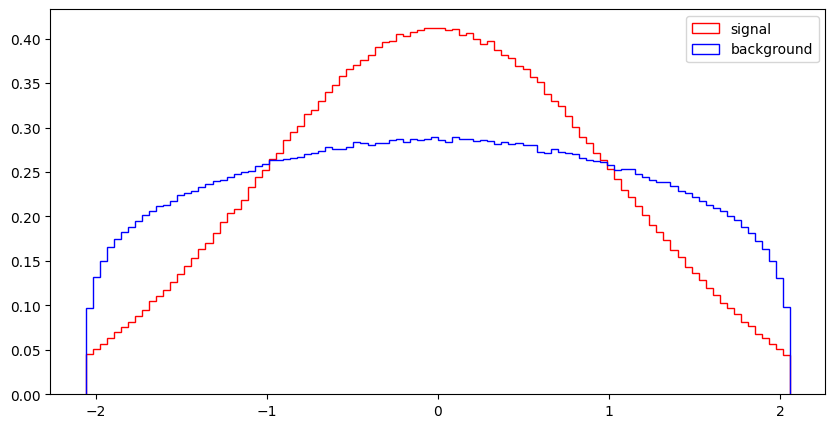

l_2_phi


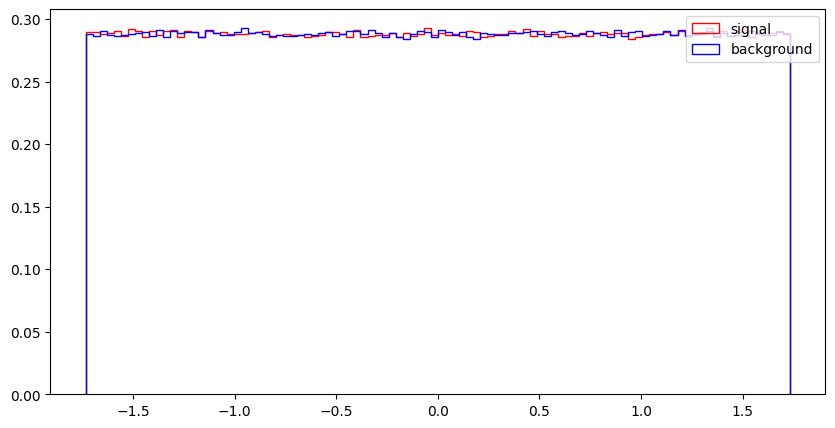

MET


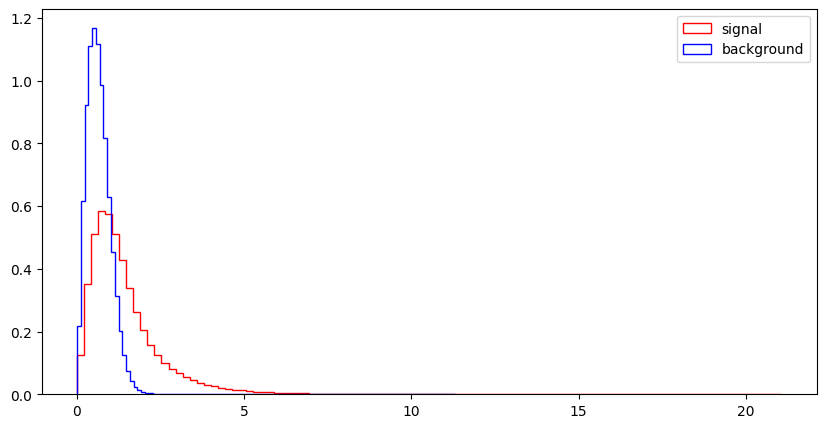

MET_phi


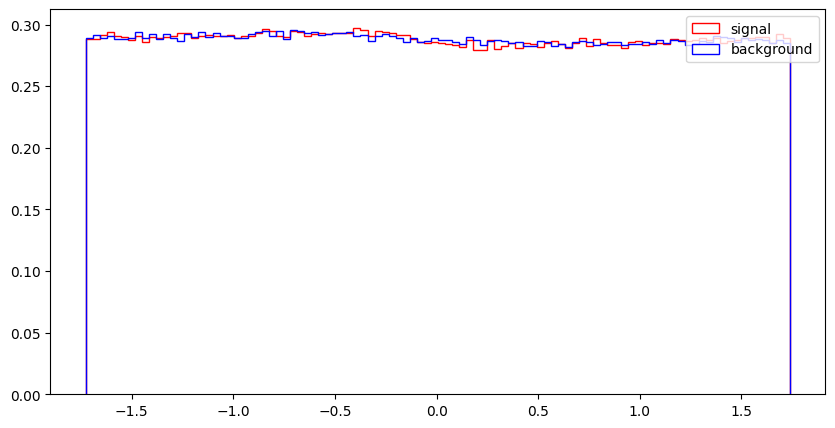

MET_rel


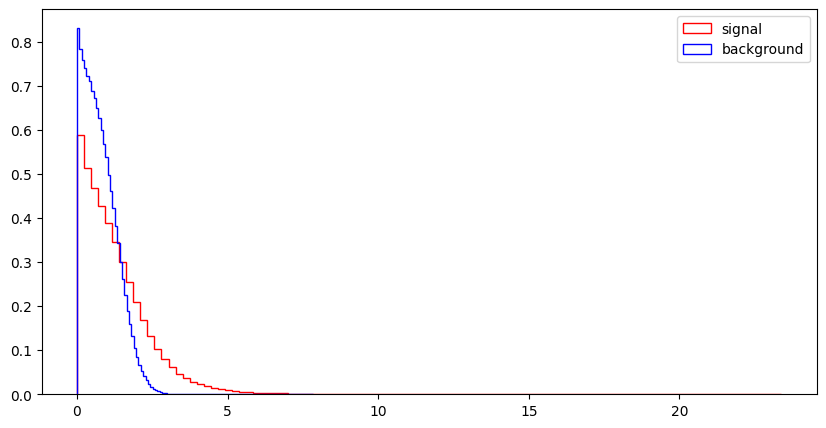

axial_MET


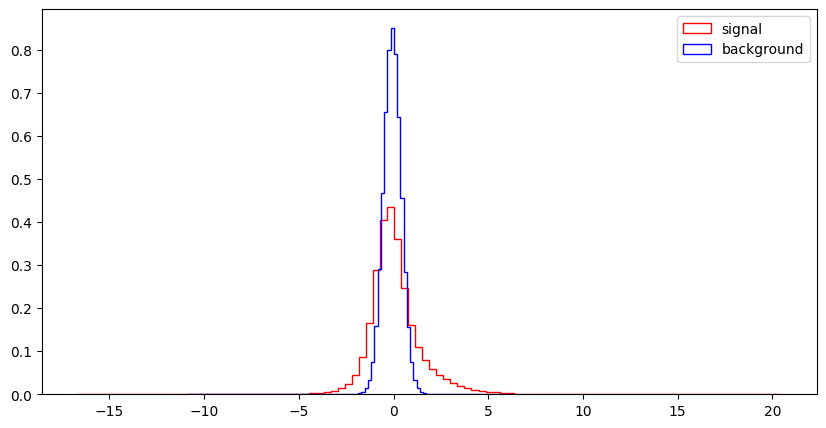

M_R


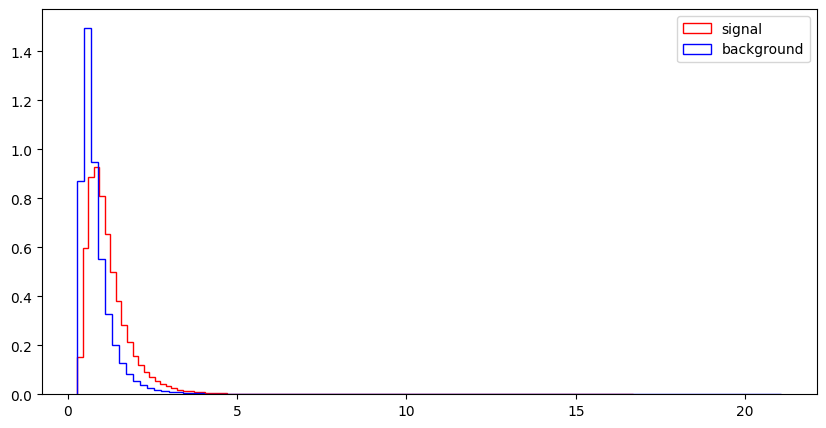

M_TR_2


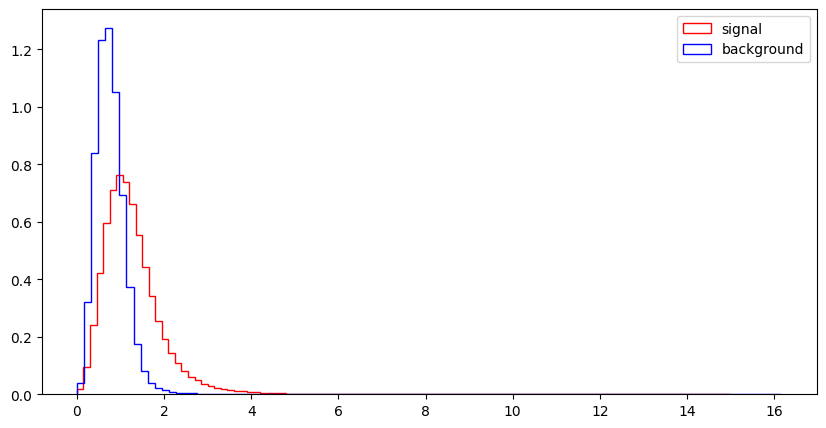

R


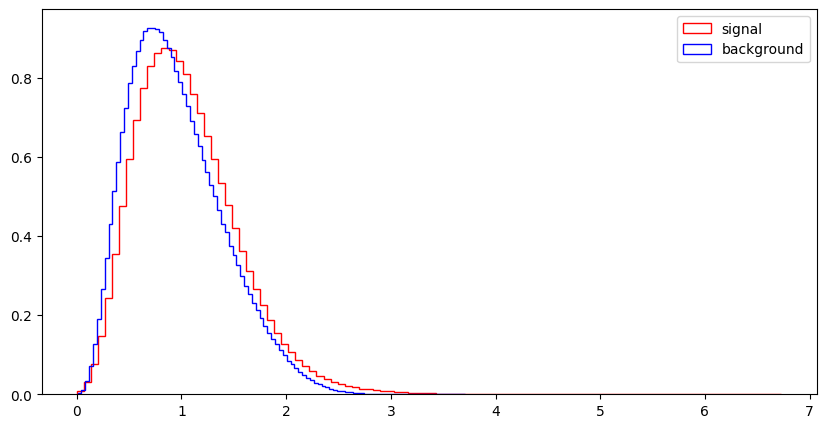

MT2


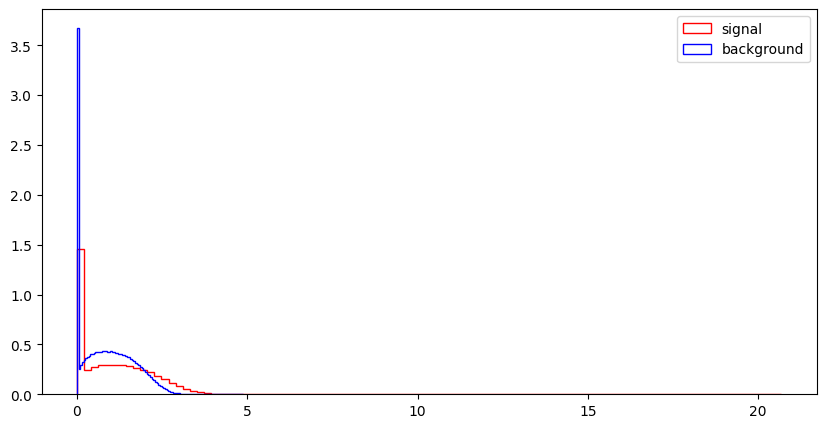

S_R


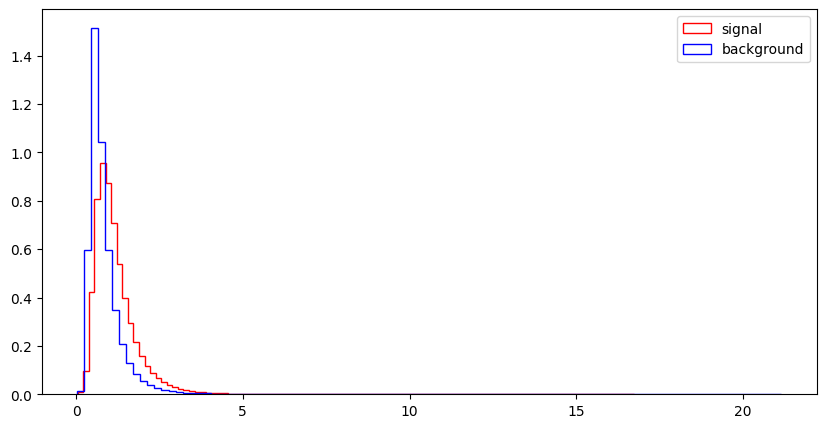

M_Delta_R


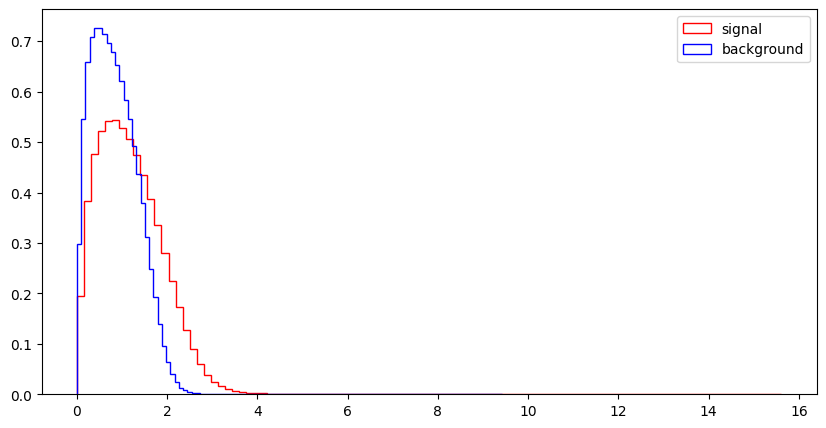

dPhi_r_b


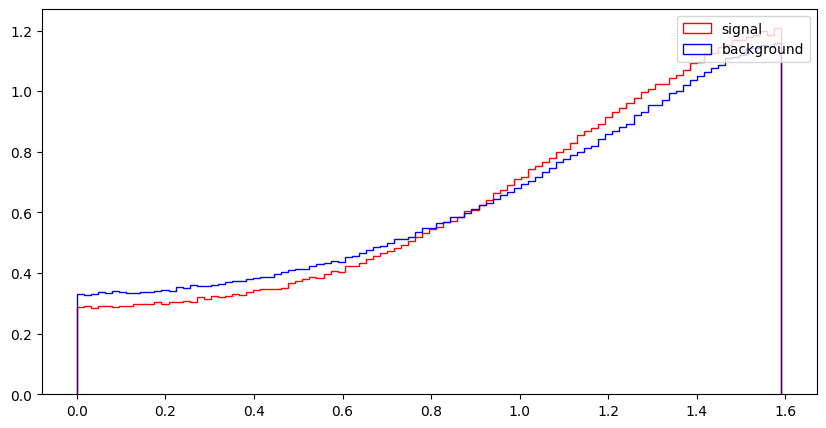

cos_theta_r1


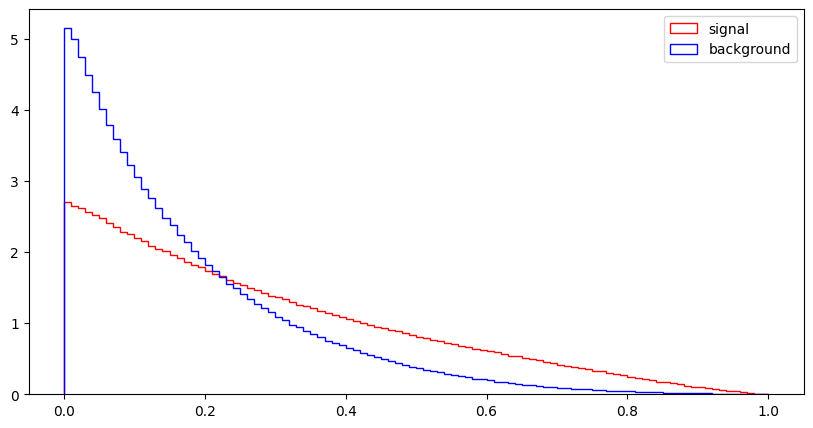

In [19]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

The paper has charts very similar to the ones shown at the end of exercise 2, essentially we are charting everything within VarNames. As described prior, we will be using the SUSY-small.csv file for operations here on out. In figure 5, it has data that is not lepton/n jets/etc so I take it that we are only seeking to format it in the same manner. Figure 6 features data points very similarly to what is seen above. Below, we will have the visual representation that will mimic what is seen in figures 5 and 6.

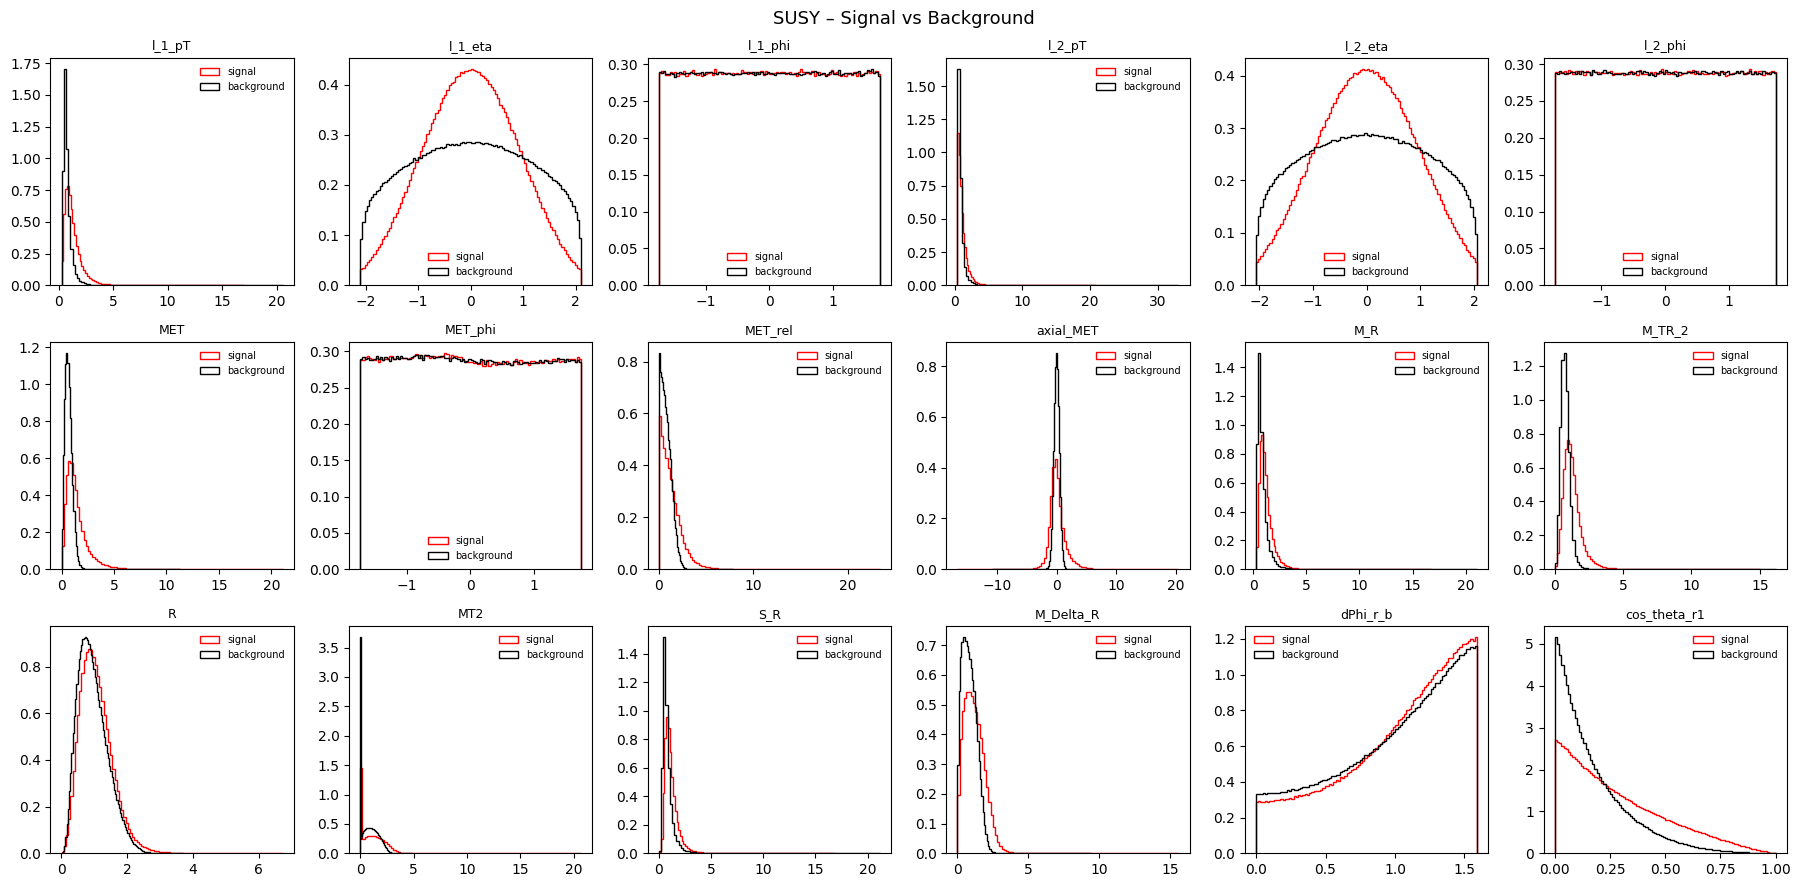

In [20]:
# I omitted this one and left it since it was already made, the code cell below is the final submission, this was just the first iteration

import numpy as np
import matplotlib.pyplot as plt

# Still working with the VarNames[1:] library like the one before

n_vars = len(VarNames[1:])
ncols = 6
nrows = int(np.ceil(n_vars / ncols))  # 3 rows of 6

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 9))
axes = axes.flatten()

for ax, var in zip(axes, VarNames[1:]):
    ax.hist(np.array(df_sig[var]), bins=100, histtype="step",
            color="red",   label="signal",     density=True, stacked=True)
    ax.hist(np.array(df_bkg[var]), bins=100, histtype="step",
            color="black", label="background", density=True, stacked=True)
    ax.set_title(var, fontsize=9)
    ax.legend(fontsize=7, frameon=False)

# Hide any leftover empty axes
for ax in axes[n_vars:]:
    ax.set_visible(False)

fig.suptitle("SUSY – Signal vs Background", fontsize=13)
fig.tight_layout()
plt.show()

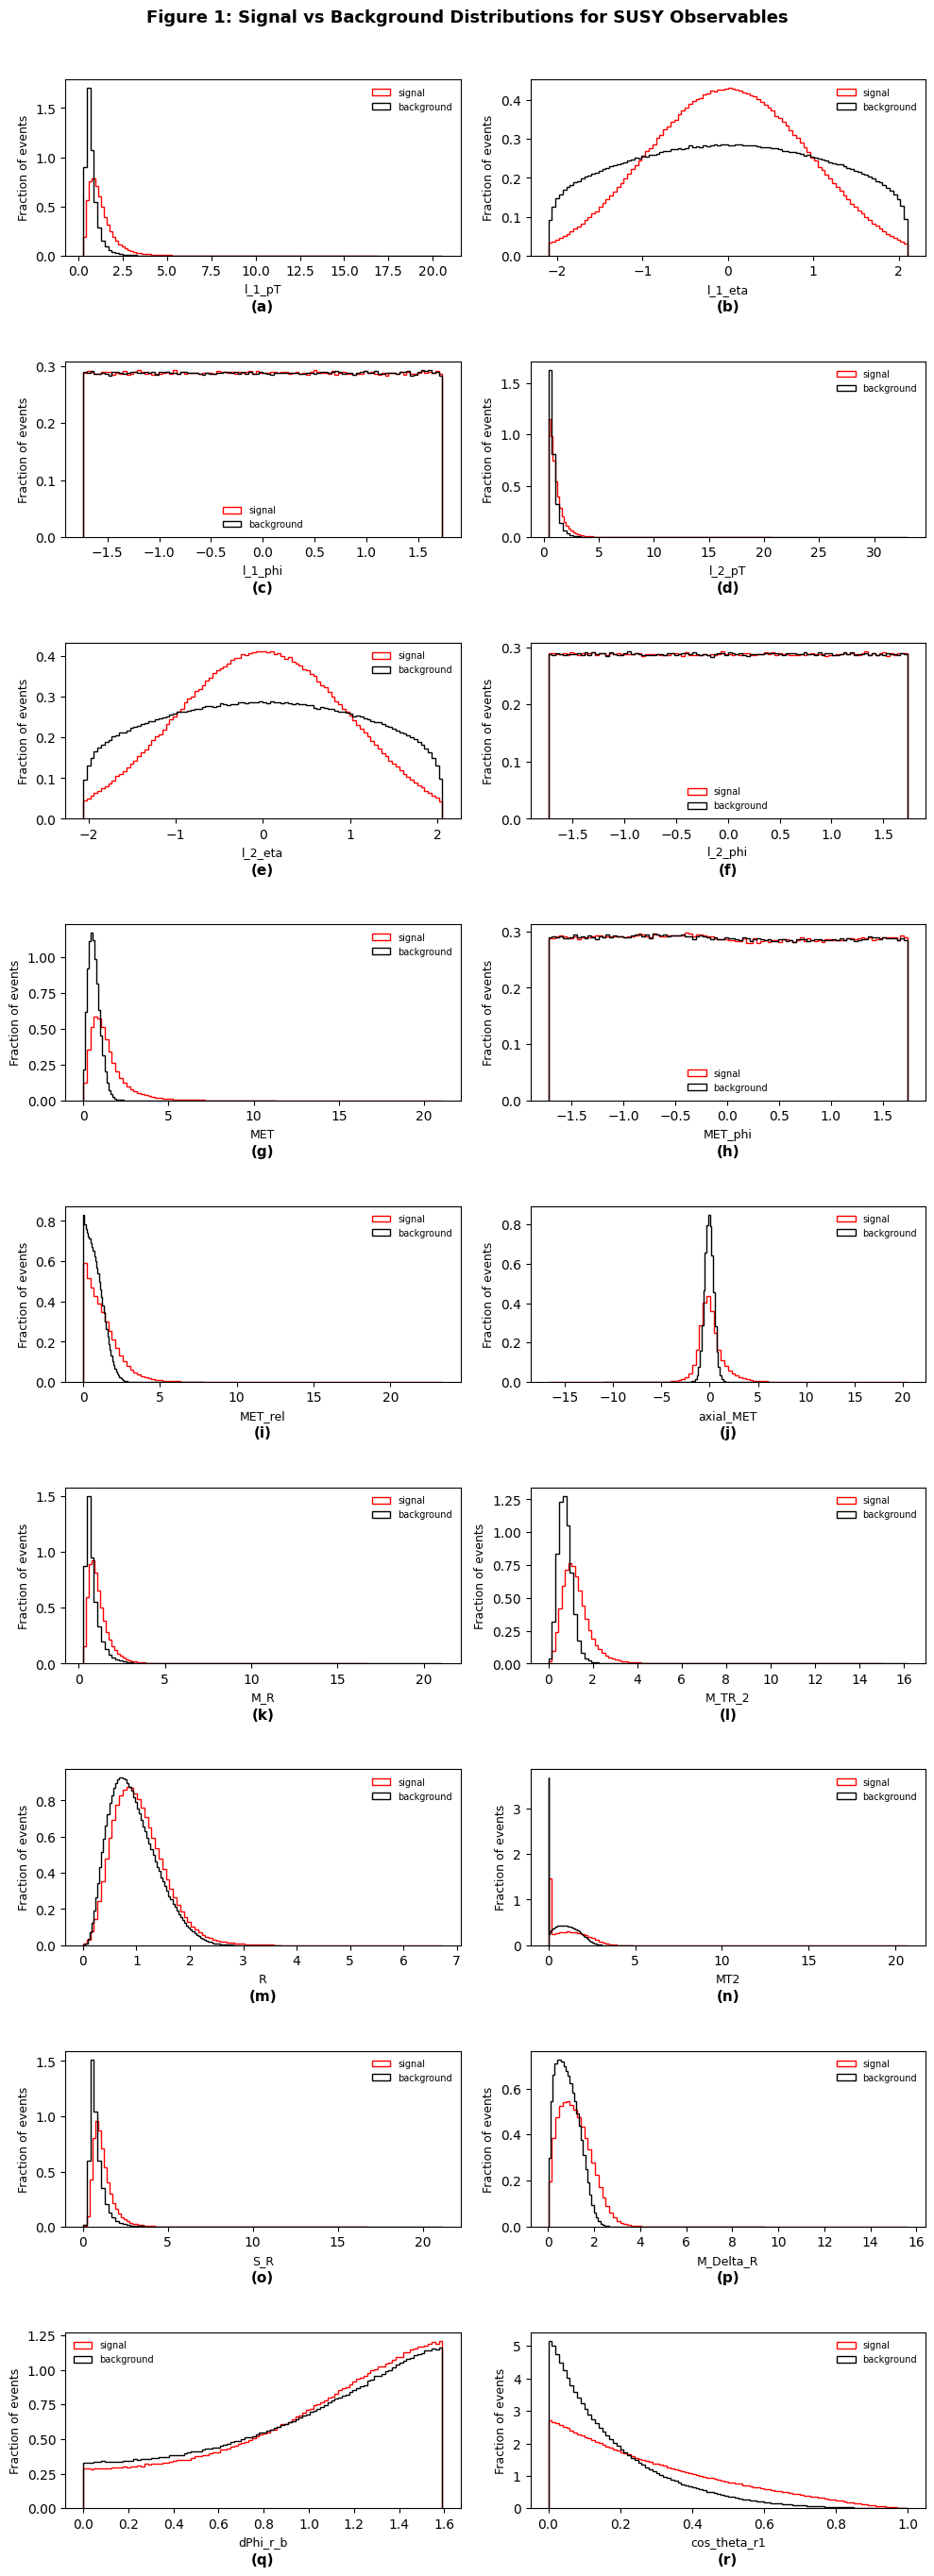

Key:
  (a)  l_1_pT
  (b)  l_1_eta
  (c)  l_1_phi
  (d)  l_2_pT
  (e)  l_2_eta
  (f)  l_2_phi
  (g)  MET
  (h)  MET_phi
  (i)  MET_rel
  (j)  axial_MET
  (k)  M_R
  (l)  M_TR_2
  (m)  R
  (n)  MT2
  (o)  S_R
  (p)  M_Delta_R
  (q)  dPhi_r_b
  (r)  cos_theta_r1

In context, this would be included as a figure and a greater text
can correspond with specific labels using (a), (b), and so on


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Slice off the 'signal' label at index 0, leaving only the 18 observable names
# We do not want to list Signal as an individual hist
vars_list = VarNames[1:]

# Set 2 histograms per row as seen in figures
ncols = 2

# Calculate the number of rows needed to fit all variables at 2 per row
nrows = int(np.ceil(len(vars_list) / ncols))

# Generate alphabetical labels (a), (b), ... , (r) — one per variable
# Uses chr() to convert integers to characters: chr(97) = 'a', chr(98) = 'b', etc.
# These replace titles and correspond to the printed key below
labels = [f"({chr(97 + i)})" for i in range(len(vars_list))]

# Create the figure and grid of subplots
# figsize scales height dynamically so rows don't get cramped as nrows grows
fig, axes = plt.subplots(nrows, ncols, figsize=(10, nrows * 3))

# Flatten the 2D array of axes into 1D so we can iterate over it easily
axes = axes.flatten()

# Loop over each variable, its corresponding subplot, and its letter label
for ax, var, label in zip(axes, vars_list, labels):

    # Plot normalised signal distribution in red
    ax.hist(np.array(df_sig[var]), bins=100, histtype="step",
            color="red", label="signal", density=True)

    # Plot normalised background distribution in black
    ax.hist(np.array(df_bkg[var]), bins=100, histtype="step",
            color="black", label="background", density=True)

    # Set the x-axis label to the variable name so each panel is self-describing
    ax.set_xlabel(var, fontsize=9)

    # Set the y-axis label to describe the normalised histogram content
    ax.set_ylabel("Fraction of events", fontsize=9)

    # Place the letter label centered below the x-axis using set_xlabel is not ideal,
    # so we use ax.text with axis coordinates (0.5, 0) to anchor it just below the panel
    ax.text(0.5, -0.25, label, transform=ax.transAxes,
            fontsize=11, fontweight="bold", ha="center", va="top")

    # Add a small legend to each panel to identify signal vs background curves
    ax.legend(fontsize=7, frameon=False)

# If the total number of variables is odd, the last subplot will be empty
# Hide it so it doesn't appear as a blank panel in the figure
for ax in axes[len(vars_list):]:
    ax.set_visible(False)

# Subtitle addition to be more in-line with figure 5 and 6
fig.suptitle("Figure 1: Signal vs Background Distributions for SUSY Observables",
             fontsize=13, fontweight="bold", y=1.01)

# Increase bottom padding so the letter labels below each panel are not clipped
fig.tight_layout()
plt.subplots_adjust(hspace=0.6)
plt.show()

# Print the key that maps each letter label back to its variable name
# This replaces the per-panel titles and allows a cleaner figure layout
# Matches the figures
print("Key:")
for label, var in zip(labels, vars_list):
    print(f"  {label}  {var}")
print("\nIn context, this would be included as a figure and a greater text")
print("can correspond with specific labels using (a), (b), and so on")

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

**For personal clarification:**

Low-level (raw) observables — RawNames — are the direct measurements that come straight out of the detector. Things like the momentum (pT), angles (eta, phi), and missing energy (MET) of the detected particles. These are the raw numbers the experiment actually measures — no extra calculation involved.

High-level (derived) features — FeatureNames — are quantities that physicists have manually engineered by combining the raw observables using their knowledge of the physics. For example, M_R, MT2, and S_R are composite variables constructed specifically because they are theoretically expected to be good at distinguishing SUSY signal events from background. They take more domain knowledge to construct but tend to carry more discriminating power.

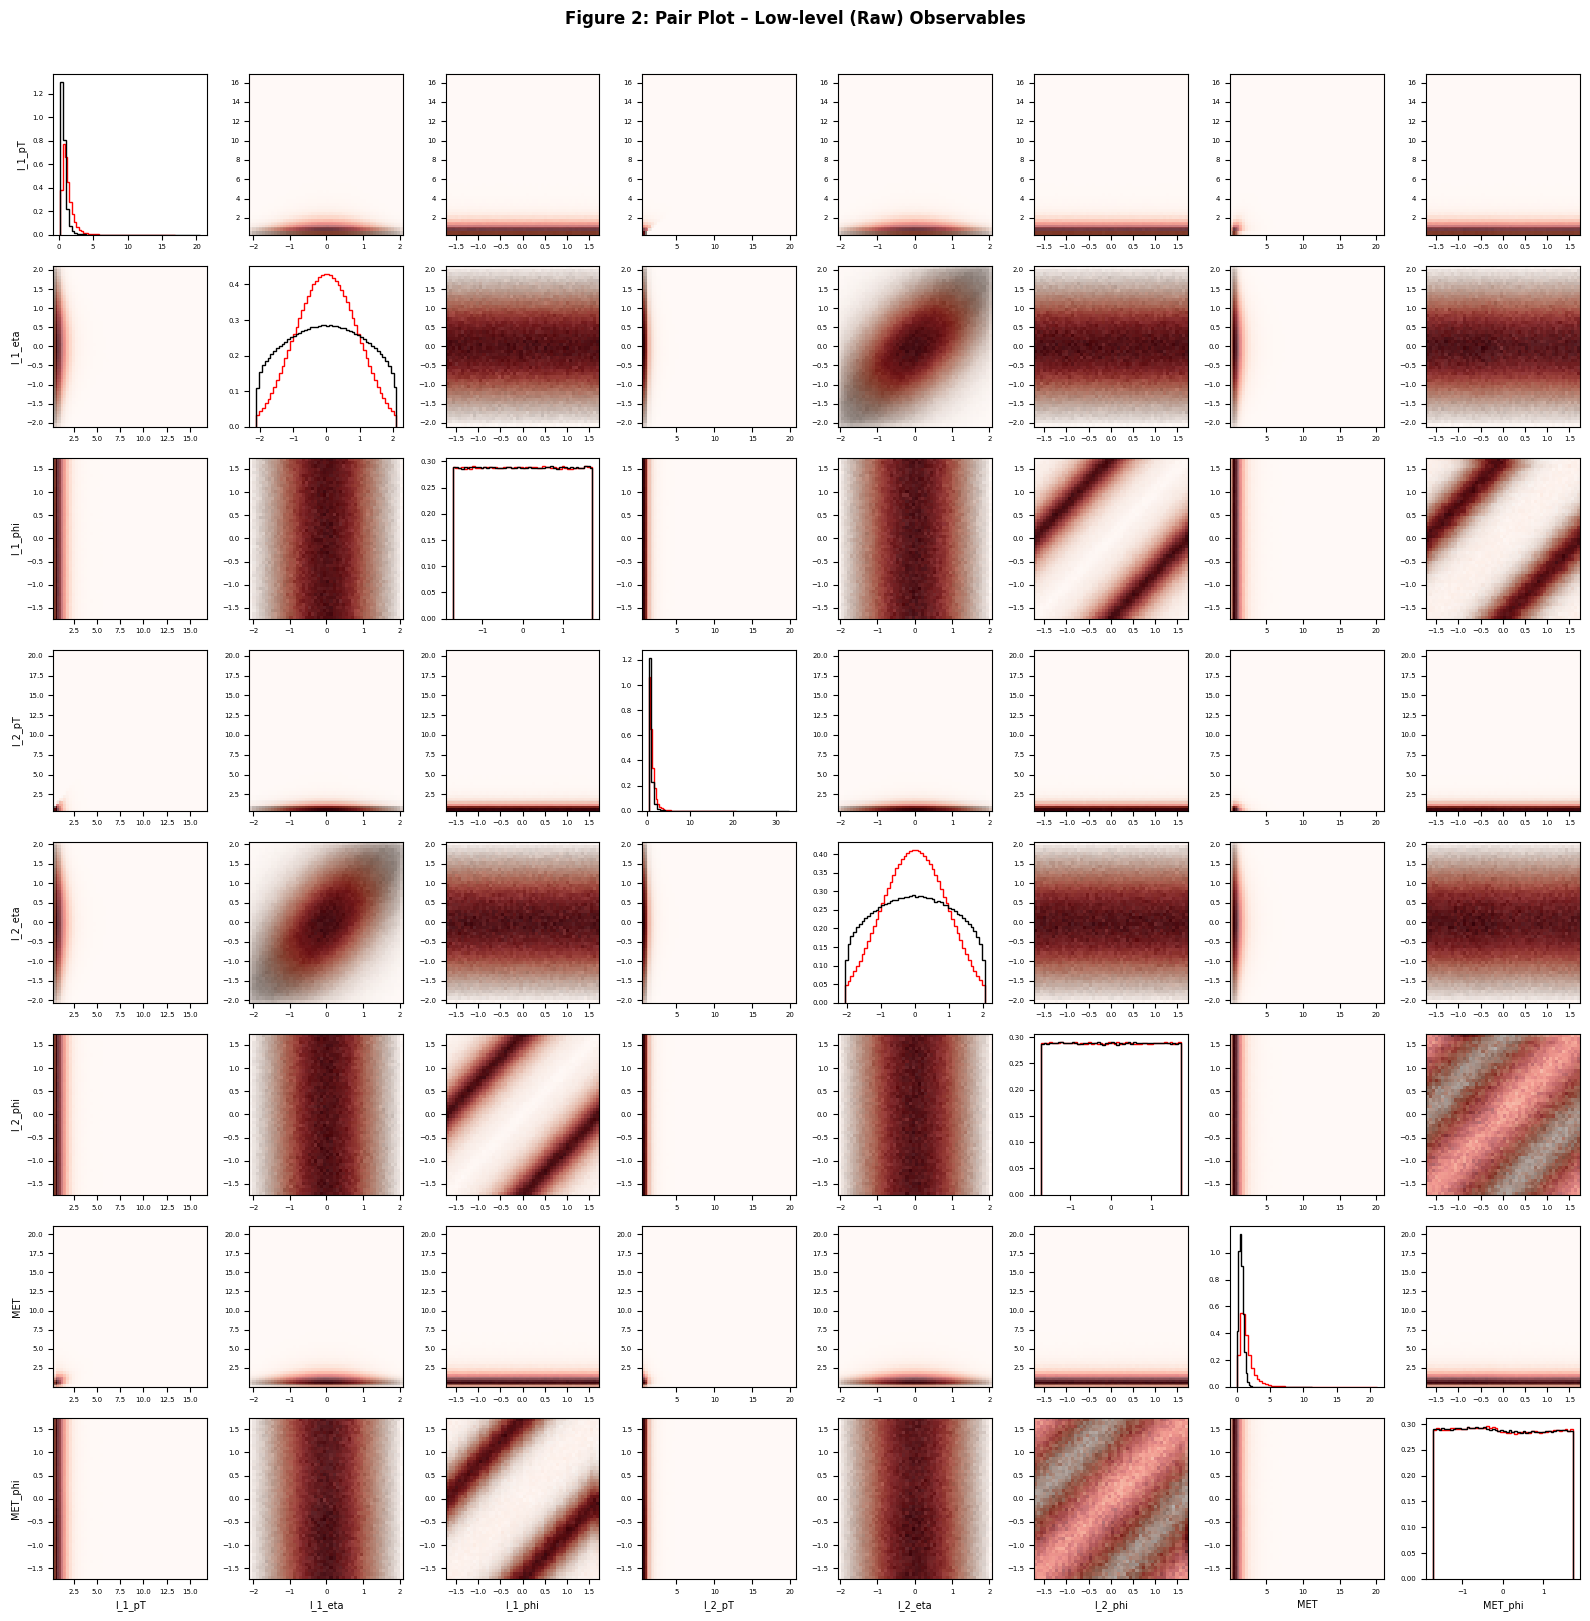

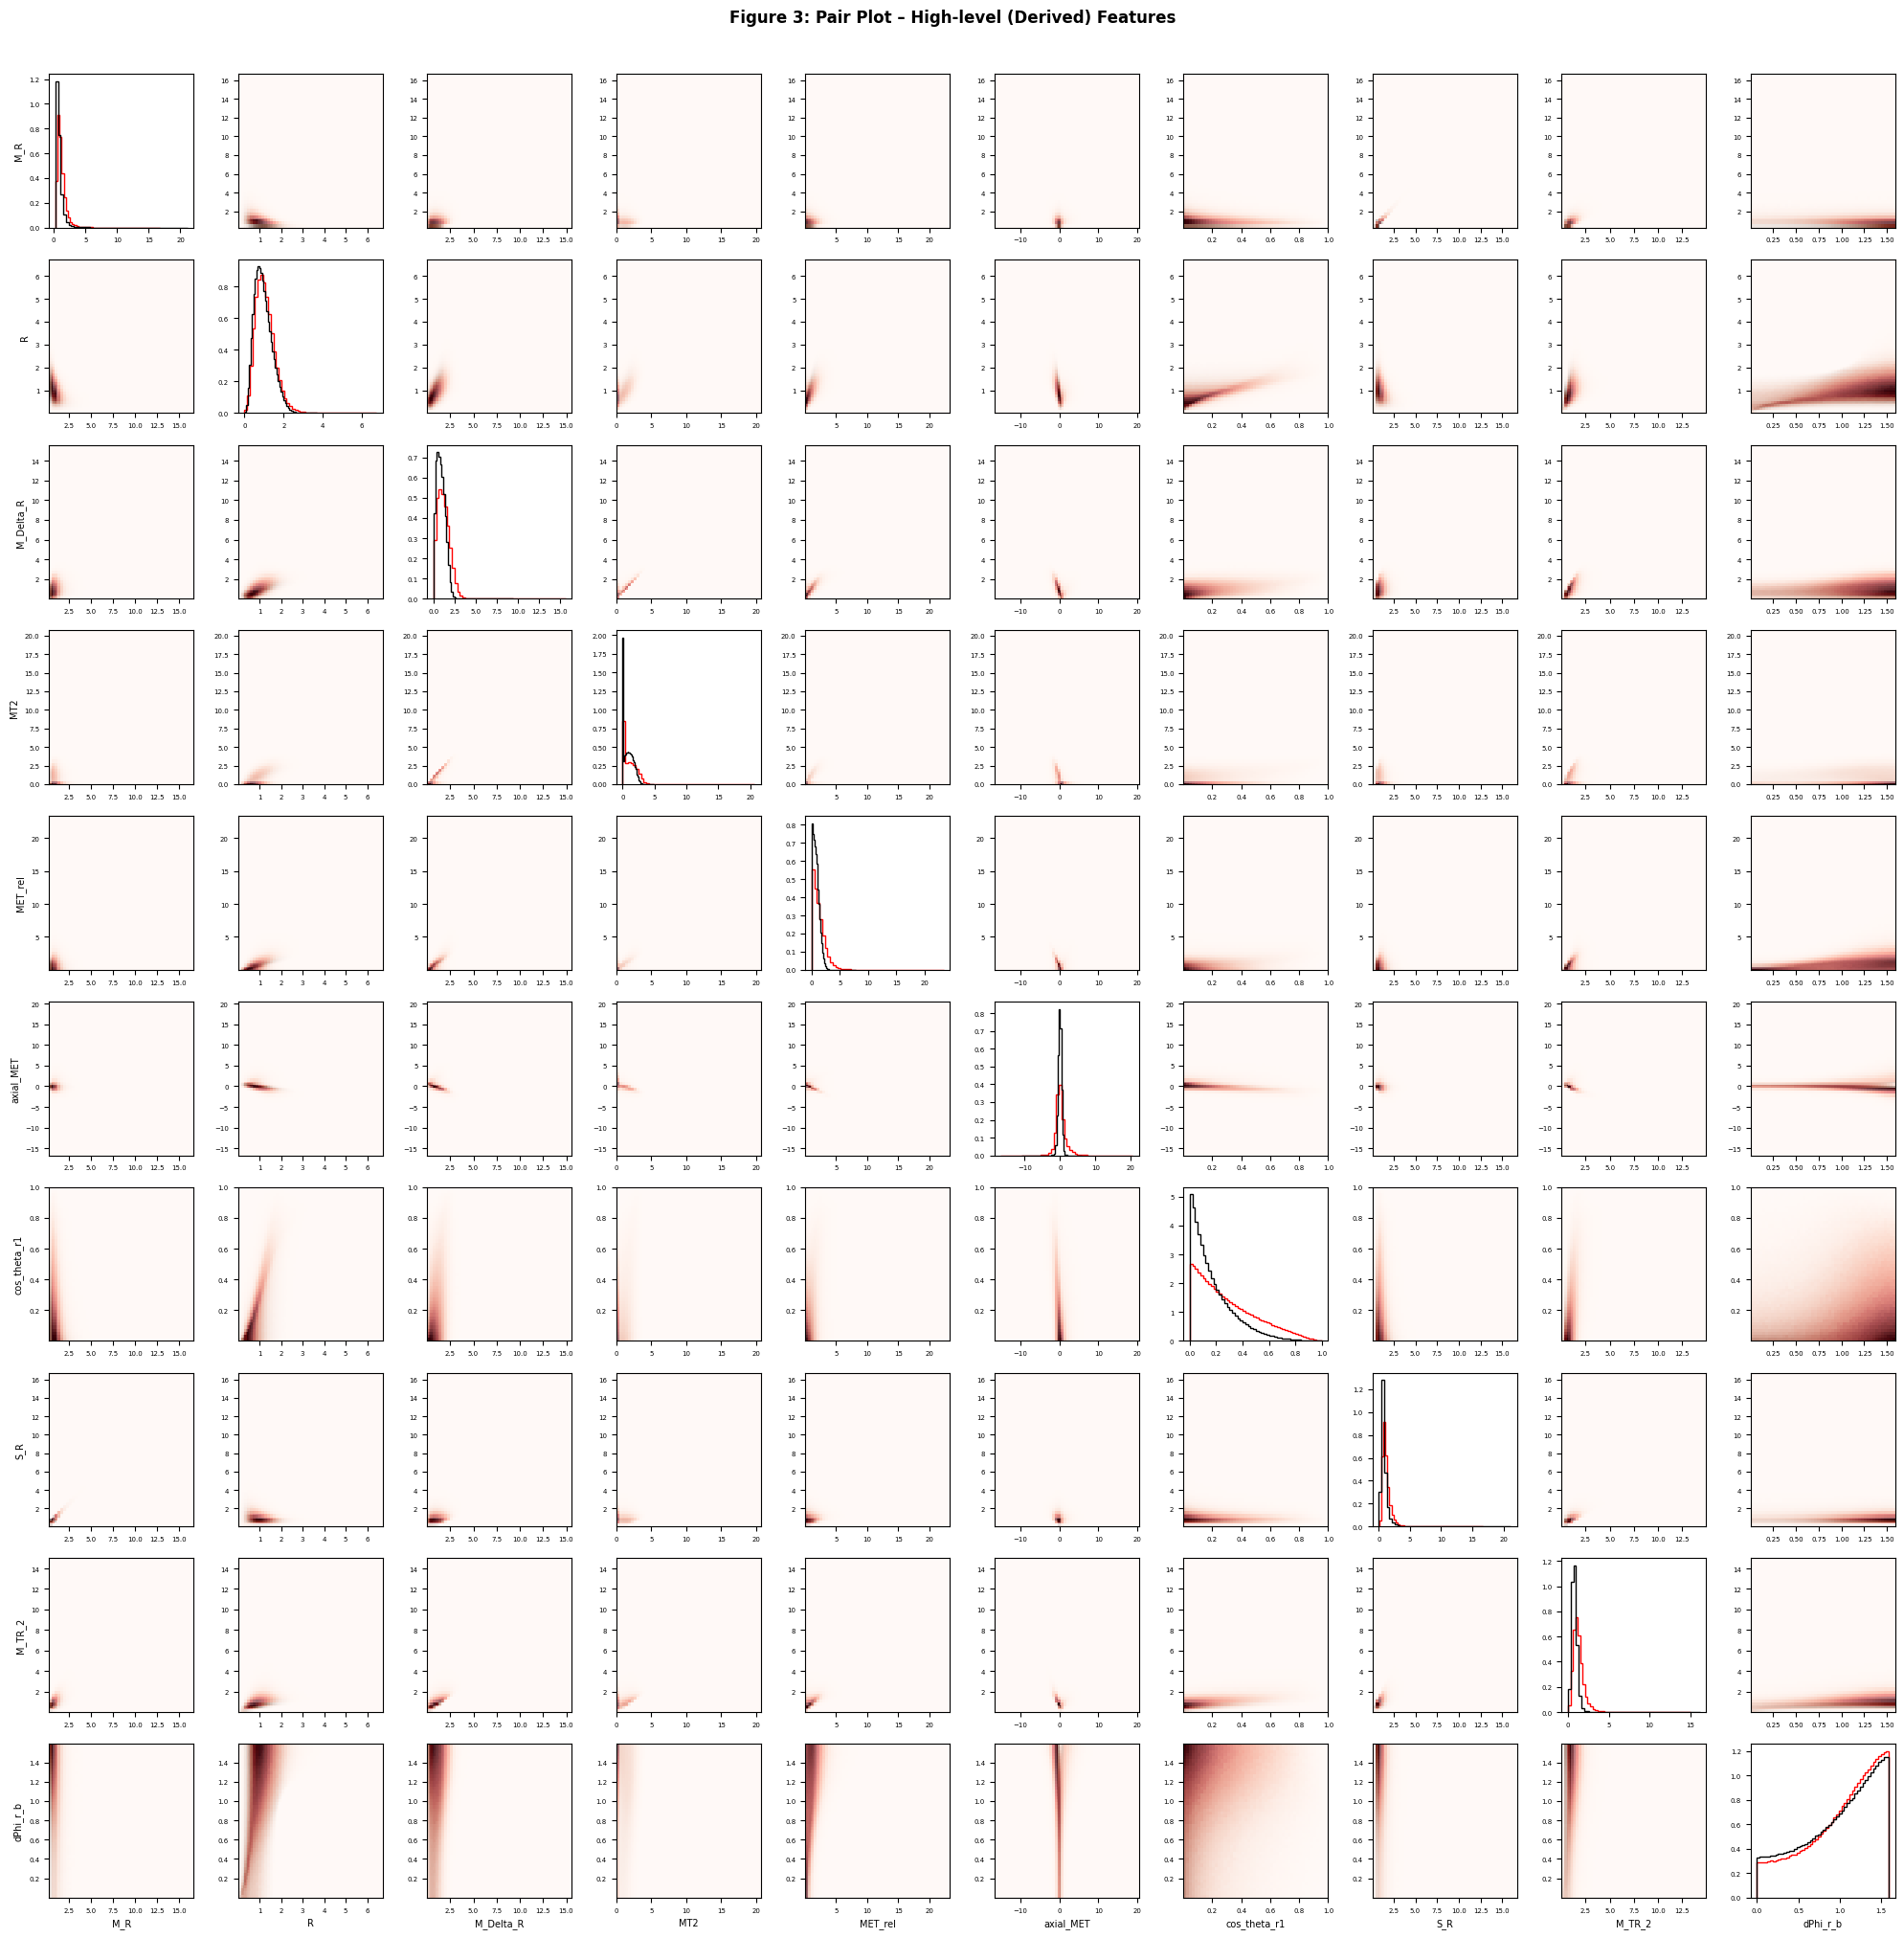

In [22]:
# Part A
# Pair plot production - high and low level - without using seaborn

import numpy as np
import matplotlib.pyplot as plt

def pair_plot(df_sig, df_bkg, var_list, title="Pair Plot"):
    # Creates pair plot comparing signal & background dist for every combination
    # of variables in its var_list

    # Along the diagonal, 1 dimensional hist show marginal dist of each var individually.
    # Off diagonal, 2 dim histograms show how pairs of variables relate

    # Parameters:
    #     df_sig   : DataFrame containing only signal events (signal == 1)
    #     df_bkg   : DataFrame containing only background events (signal == 0)
    #     var_list : list of variable name strings to include in the grid
    #     title    : overall figure title displayed above the grid

    # Number of variables determines the grid dimensions (n x n)
    n = len(var_list)

    # Create the n x n subplot grid — each cell is one variable pair
    fig, axes = plt.subplots(n, n, figsize=(n * 2, n * 2))

    # Loop over every combination of variables for the y and x axes
    for i, var_y in enumerate(var_list):
        for j, var_x in enumerate(var_list):

            ax = axes[i, j]

            if i == j:
                # Diagonal paenls
                # When both axes represent the same variable, plot 1D histograms to show the marginal
                # distribution for signal and background, basically what has been observed before
                ax.hist(df_sig[var_x], bins=50, histtype="step",
                        color="red",   density=True)
                ax.hist(df_bkg[var_x], bins=50, histtype="step",
                        color="black", density=True)

            else:
                # Off-diagonal panels
                # Plot 2D histograms for each pair of variables. hist2d is used instead of scatter for performance — scatter
                # renders one point per event (up to 500k), whereas hist2d bins the data into a fixed grid first, making it much faster.
                # Background is plotted first in greyscale, signal overlaid in red with transparency so both are visible where they overlap.
                ax.hist2d(df_bkg[var_x], df_bkg[var_y], bins=50,
                          cmap="Greys", density=True)
                ax.hist2d(df_sig[var_x], df_sig[var_y], bins=50,
                          cmap="Reds",  density=True, alpha=0.5)

            # Axis labels
            # Only label the bottom row (x) and left column (y) to avoid
            # cluttering the interior of the grid with repeated labels
            if i == n - 1:
                ax.set_xlabel(var_x, fontsize=7)
            if j == 0:
                ax.set_ylabel(var_y, fontsize=7)

            # Shrink tick labels so they fit within the small panel size
            ax.tick_params(labelsize=5)

    # Add an overall title above the grid, like the first figure
    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.01)

    # Tighten spacing between panels so labels and plots don't overlap
    fig.tight_layout()
    plt.show()


# Test - Generate pair plots for low-level and high-level variables

# Low-level raw observables — direct detector measurements (8 x 8 grid)
# Expect relatively poor signal/background separation in most panels
pair_plot(df_sig, df_bkg, RawNames,
          title="Figure 2: Pair Plot – Low-level (Raw) Observables")

# High-level derived features — physicist-engineered composite variables (10 x 10 grid)
# Expect stronger separation, particularly in M_R, MT2, S_R, and M_TR_2
pair_plot(df_sig, df_bkg, FeatureNames,
          title="Figure 3: Pair Plot – High-level (Derived) Features")

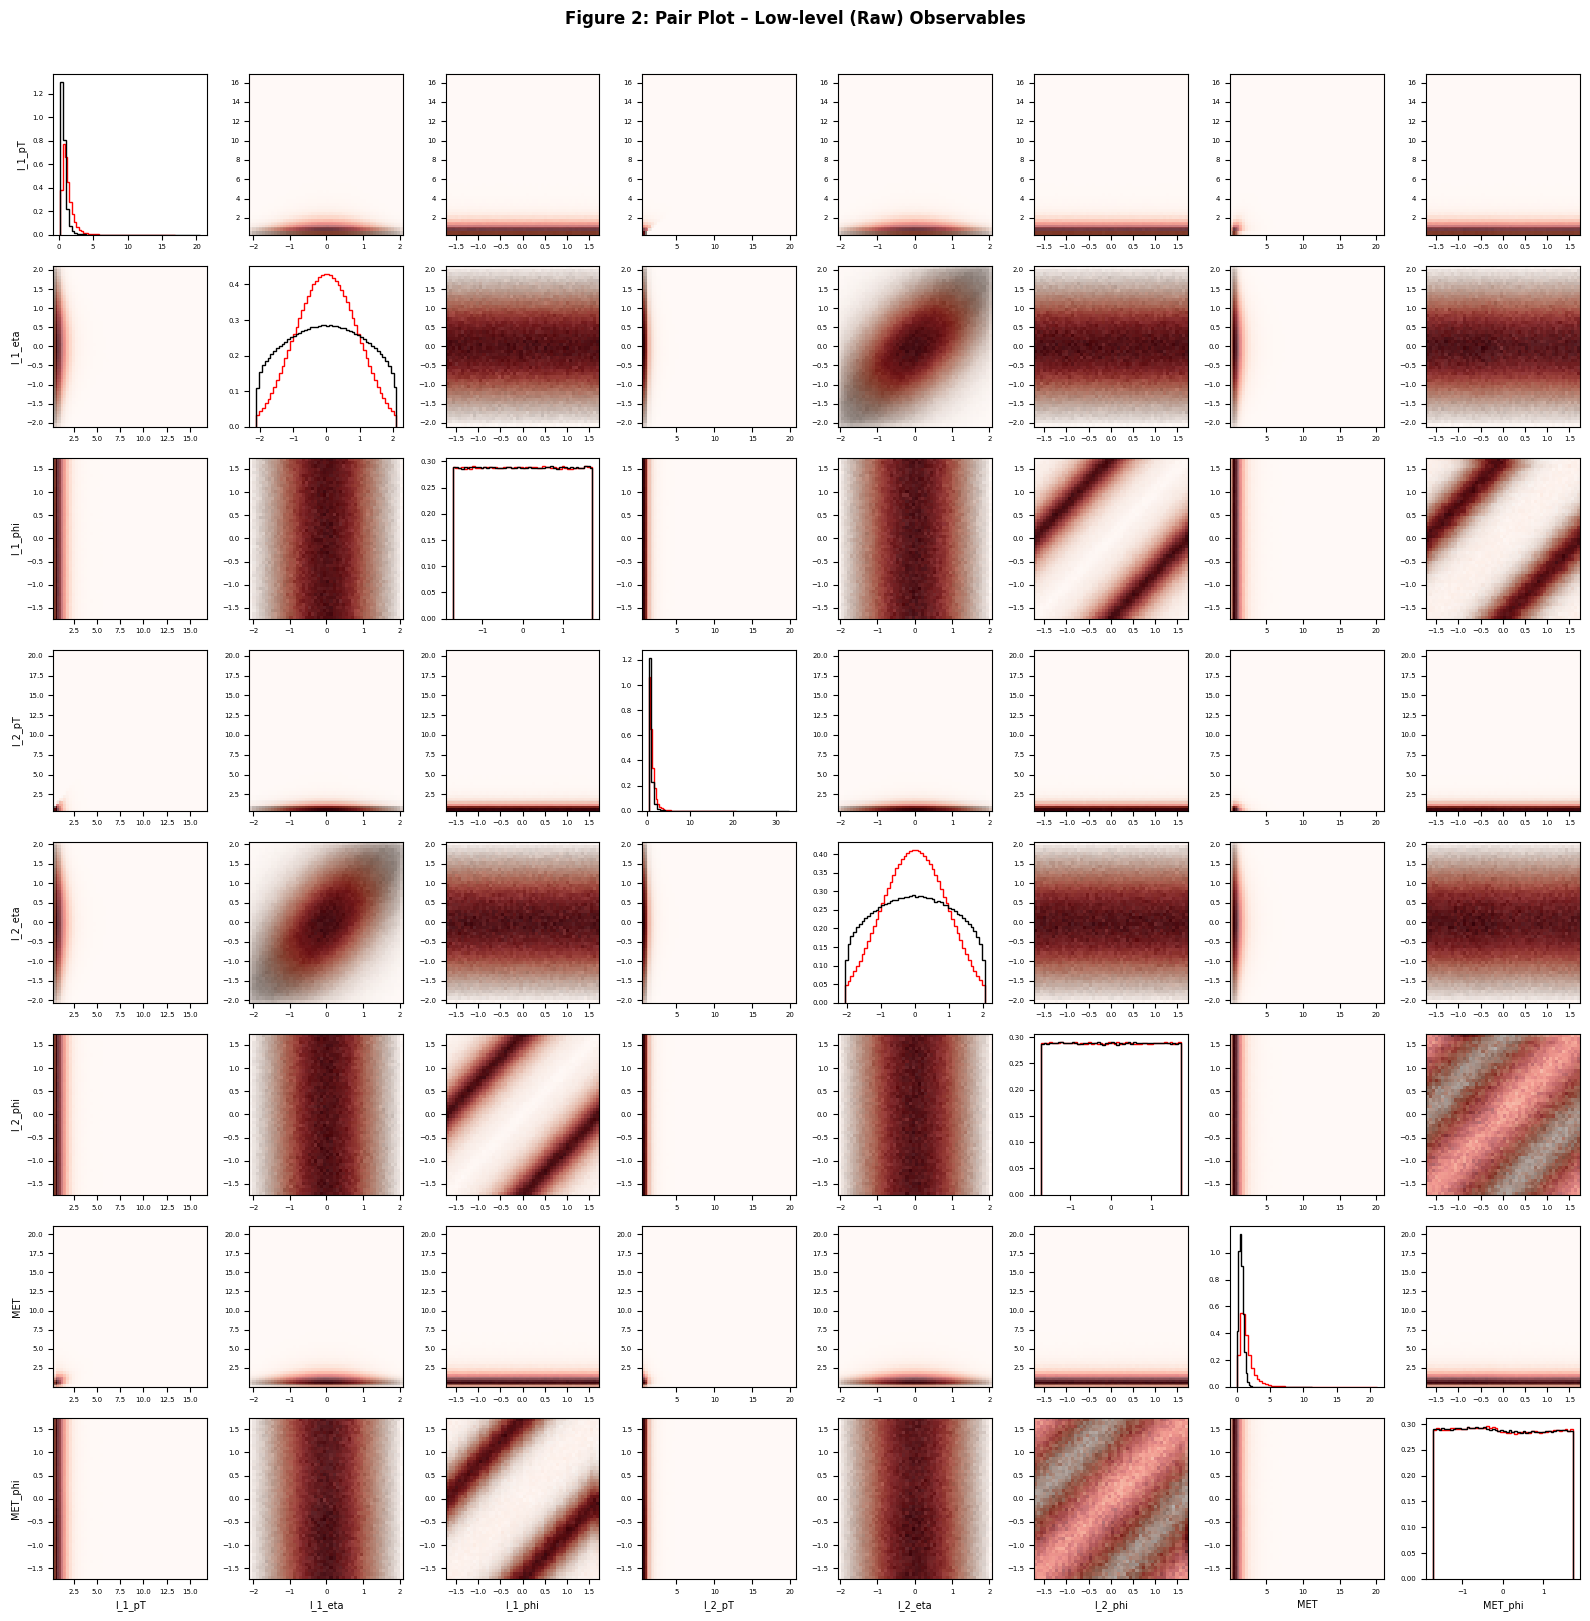

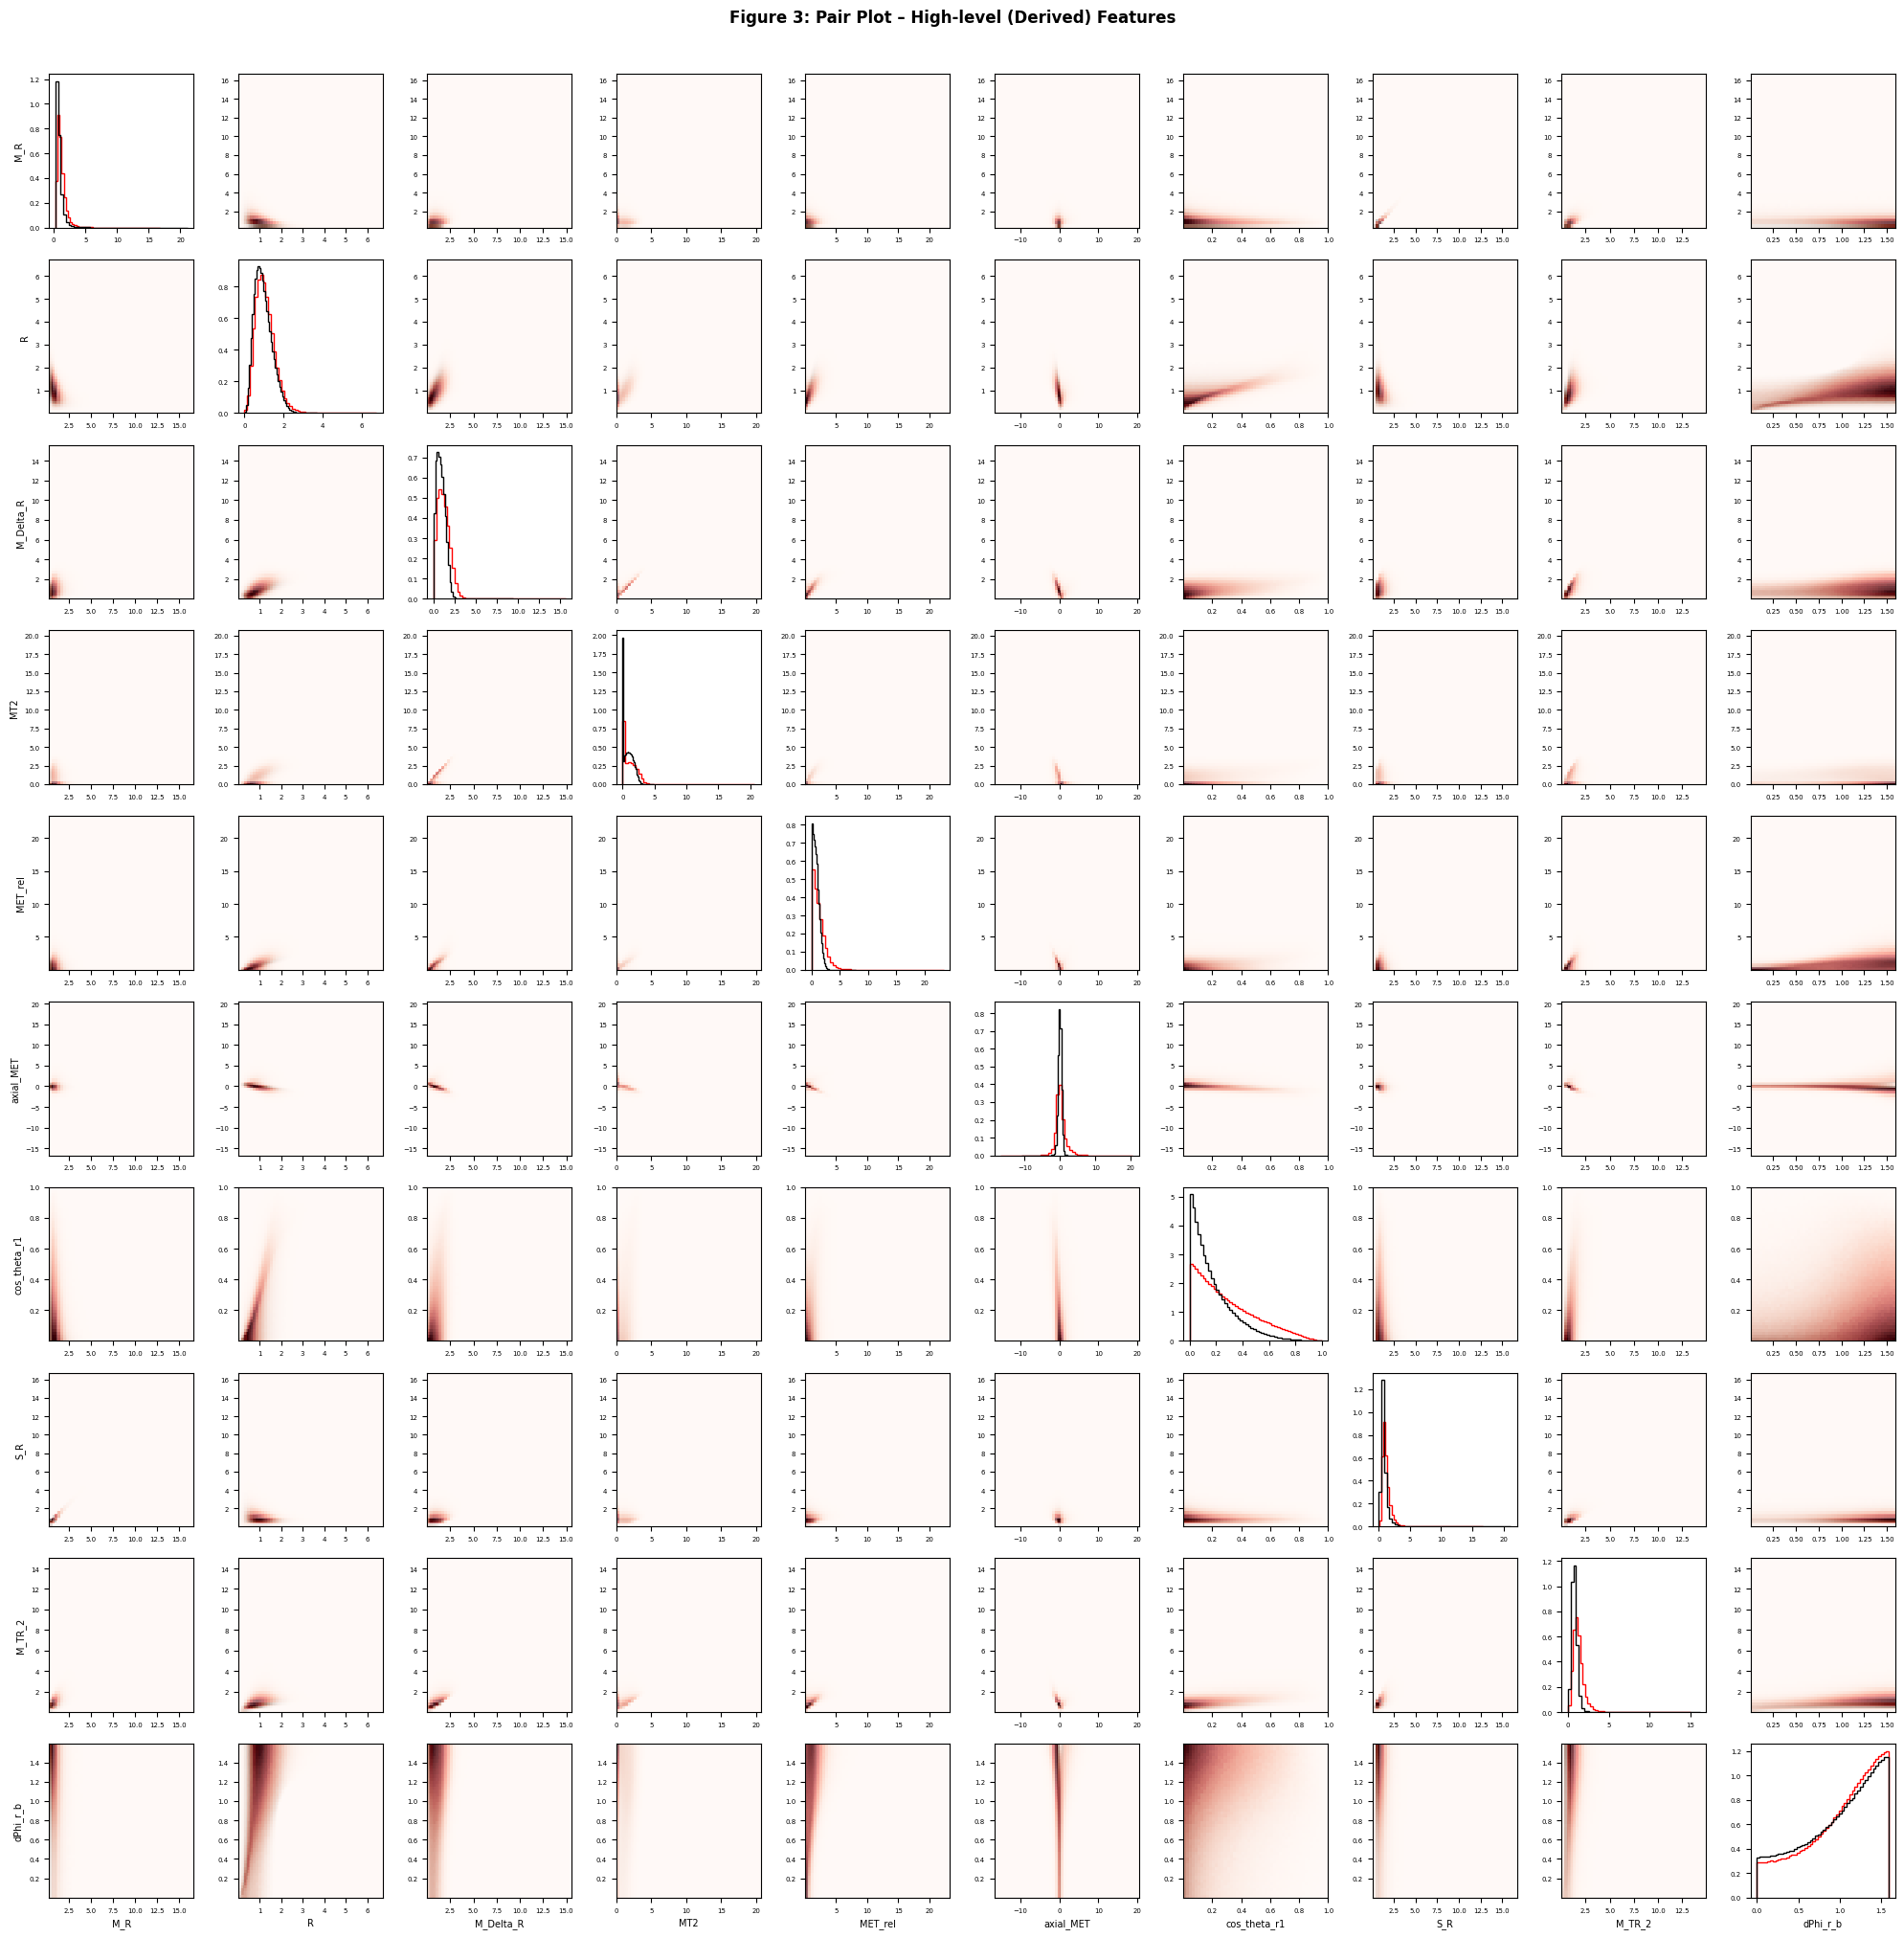

In [23]:
# Part B
# Speed up the process, this will be the optimized version from part A.

import numpy as np
import matplotlib.pyplot as plt

def pair_plot_fast(df_sig, df_bkg, var_list, title="Pair Plot"):
    # What differs here from the prior is optimizations such as pre-extraction
    # All columns are converted to numpy arrays once before the loop begins.
    # Prior, the signla and background were called on every iteration of the double loop, meaning
    # that pandas performed repeated column lookups. Storing arrays in a dict reduces this to a single
    # pass over the data upfront.

    # The other feature to improve speed was hist2d over scatter, though this carried over from part A
    
    n = len(var_list)

    # Speed improvement 1: pre-extract columns as numpy arrays
    # Convert all required columns to numpy arrays once before the loop.
    # This avoids repeated pandas column lookups inside the n x n iteration.
    sig_arrays = {var: df_sig[var].to_numpy() for var in var_list}
    bkg_arrays = {var: df_bkg[var].to_numpy() for var in var_list}

    # Create the n x n subplot grid
    fig, axes = plt.subplots(n, n, figsize=(n * 2, n * 2))

    for i, var_y in enumerate(var_list):
        for j, var_x in enumerate(var_list):

            ax = axes[i, j]

            # Retrieve the pre-computed arrays from the dictionary
            # rather than querying the DataFrame on every iteration
            # This is the process thatll make it faster
            sig_x = sig_arrays[var_x]
            bkg_x = bkg_arrays[var_x]
            sig_y = sig_arrays[var_y]
            bkg_y = bkg_arrays[var_y]

            if i == j:
                # Diagonal: 1D marginal distributions
                ax.hist(sig_x, bins=50, histtype="step",
                        color="red",   density=True)
                ax.hist(bkg_x, bins=50, histtype="step",
                        color="black", density=True)

            else:
                # Off-diagonal: 2D histograms
                # Speed improvement 2 (carried from part a): hist2d bins the
                # data into a fixed grid before rendering, making it much faster
                # than scatter which draws one point per event
                ax.hist2d(bkg_x, bkg_y, bins=50, cmap="Greys", density=True)
                ax.hist2d(sig_x, sig_y, bins=50, cmap="Reds",  density=True,
                          alpha=0.5)

            # Only label outer edges to keep the interior clean
            if i == n - 1:
                ax.set_xlabel(var_x, fontsize=7)
            if j == 0:
                ax.set_ylabel(var_y, fontsize=7)

            ax.tick_params(labelsize=5)

    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()


# Part (b): Call the optimised function

pair_plot_fast(df_sig, df_bkg, RawNames,
               title="Figure 2: Pair Plot – Low-level (Raw) Observables")

pair_plot_fast(df_sig, df_bkg, FeatureNames,
               title="Figure 3: Pair Plot – High-level (Derived) Features")

In [24]:
# Part C
# Staying in a code cell format since the prior 2 were code cells

# Low-level (raw) observables — RawNames:
# - l_1_pT and l_1_eta appear decent, can be separated from the background. Same
#   can be said for any iteration of pT and eta. Any iteration of phi was virtually
#   indistinguishable from the background when looking at the signal.

# High-level (derived) features — FeatureNames:
# - Some that can be utilized for separating the signal from the background can be the MET,
#   TR_2, theta_r1, and MET_rel. Others can be utilized, but these are the ones that immediately
#   stand out.

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [25]:
# Part A
# Installed, here is a simple test

try:
    import tabulate
    print("tabulate imported successfully, version:", tabulate.__version__)
except ImportError:
    print("tabulate not found — install it with: pip install tabulate")

tabulate imported successfully, version: 0.10.0


In [27]:
# Part B

# Extract all observables (excluding the signal label) as a numpy array
# Rows = events, columns = variables
all_data     = df[VarNames[1:]].to_numpy()
raw_data     = df[RawNames].to_numpy()
feature_data = df[FeatureNames].to_numpy()

# Covariance matrices
# np.cov expects variables as rows, so we transpose (each row = one variable)
cov_all      = np.cov(all_data.T)
cov_raw      = np.cov(raw_data.T)
cov_features = np.cov(feature_data.T)

# Correlation matrices
# np.corrcoef normalises the covariance so all diagonal entries are 1,
# giving a scale-independent measure of linear relationship between variables
corr_all      = np.corrcoef(all_data.T)
corr_raw      = np.corrcoef(raw_data.T)
corr_features = np.corrcoef(feature_data.T)

# Tester - All should come otu to be 1
print("Diagonal of full correlation matrix (should all be 1.0):")
print(np.diag(corr_all).round(6))

Diagonal of full correlation matrix (should all be 1.0):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [30]:
# Part C

# Using gpt to learn tabulate, and it used html, display from ipython.
# I assume if it is from ipython it would be a standard library
from IPython.display import HTML, display
import tabulate as tab

def display_matrix(matrix, var_names, title, fmt=".3f"):
    # Formats a matrix as an HTML table with variable names as headers.

    # Build rows: prepend each row with its variable name as a row label
    # format(val, fmt) controls decimal places for each matrix entry
    rows = [[var_names[i]] + [format(val, fmt) for val in row]
            for i, row in enumerate(matrix)]

    # Print title above table, then render as HTML in the notebook
    print(title)
    display(HTML(tab.tabulate(rows, headers=[""] + var_names, tablefmt="html")))


# Testing section

# Raw - low level
# Covariance shows absolute spread, correlation shows scale-independent relationship
display_matrix(cov_raw,       RawNames,     "Covariance – Raw Observables")
display_matrix(corr_raw,      RawNames,     "Correlation – Raw Observables")

# Hiwh level
display_matrix(cov_features,  FeatureNames, "Covariance – High-level Features")
display_matrix(corr_features, FeatureNames, "Correlation – High-level Features")

# all obeservables
display_matrix(cov_all,       VarNames[1:], "Covariance – All Observables")
display_matrix(corr_all,      VarNames[1:], "Correlation – All Observables")

Covariance – Raw Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.472,-0,-0,0.308,-0,0,0.231,-0.001
l_1_eta,-0,1.006,0,-0,0.406,0,-0.001,-0.001
l_1_phi,-0,0,1.003,-0,0.001,-0.268,0.001,-0.184
l_2_pT,0.308,-0,-0,0.428,-0,0,0.08,-0.001
l_2_eta,-0,0.406,0.001,-0,1.006,-0,0,-0
l_2_phi,0,0,-0.268,0,-0,1.003,0,-0.034
MET,0.231,-0.001,0.001,0.08,0,0,0.762,-0.002
MET_phi,-0.001,-0.001,-0.184,-0.001,-0,-0.034,-0.002,1.003


Correlation – Raw Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0,-0,0.685,-0,0,0.385,-0.001
l_1_eta,-0,1,0,-0.001,0.403,0,-0.001,-0.001
l_1_phi,-0,0,1,-0,0.001,-0.267,0.001,-0.184
l_2_pT,0.685,-0.001,-0,1,-0.001,0,0.14,-0.002
l_2_eta,-0,0.403,0.001,-0.001,1,-0,0,-0
l_2_phi,0,0,-0.267,0,-0,1,0,-0.034
MET,0.385,-0.001,0.001,0.14,0,0,1,-0.002
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.034,-0.002,1


Covariance – High-level Features


...

,M_R,R,M_Delta_R,MT2,MET_rel,axial_MET,cos_theta_r1,S_R,M_TR_2,dPhi_r_b
M_R,1,-0.381,0.189,-0.068,0.078,0.024,-0.115,0.981,0.578,-0.106
R,-0.381,1,0.564,0.574,0.595,-0.385,0.627,-0.285,0.38,0.424
M_Delta_R,0.189,0.564,1,0.808,0.749,-0.375,0.319,0.248,0.666,0.156
MT2,-0.068,0.574,0.808,1,0.536,-0.535,0.263,-0.021,0.378,0.056
MET_rel,0.078,0.595,0.749,0.536,1,-0.141,0.317,0.149,0.583,0.378
axial_MET,0.024,-0.385,-0.375,-0.535,-0.141,1,-0.274,-0.07,-0.323,-0.06
cos_theta_r1,-0.115,0.627,0.319,0.263,0.317,-0.274,1,-0.084,0.451,0.106
S_R,0.981,-0.285,0.248,-0.021,0.149,-0.07,-0.084,1,0.636,-0.013
M_TR_2,0.578,0.38,0.666,0.378,0.583,-0.323,0.451,0.636,1,0.228
dPhi_r_b,-0.106,0.424,0.156,0.056,0.378,-0.06,0.106,-0.013,0.228,1


Covariance – All Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.472,-0,-0,0.308,-0,0,0.231,-0.001,0.099,-0.013,0.368,0.291,-0.059,-0.013,0.346,0.098,-0.047,0.023
l_1_eta,-0,1.006,0,-0,0.406,0,-0.001,-0.001,-0,-0,-0,-0,0,-0,-0,-0.001,0,0
l_1_phi,-0,0,1.003,-0,0.001,-0.268,0.001,-0.184,0.002,-0.002,-0,0.001,0.001,0.002,0,0.001,0.001,0
l_2_pT,0.308,-0,-0,0.428,-0,0,0.08,-0.001,-0.002,0.05,0.328,0.164,-0.099,-0.069,0.325,0.006,-0.004,-0.028
l_2_eta,-0,0.406,0.001,-0,1.006,-0,0,-0,0,-0,-0.001,-0,0,-0,-0.001,-0,-0,0
l_2_phi,0,0,-0.268,0,-0,1.003,0,-0.034,0,-0,0,0,0,0.001,0,0,0,-0
MET,0.231,-0.001,0.001,0.08,0,0,0.762,-0.002,0.548,0.145,0.146,0.368,0.189,0.156,0.167,0.317,0.145,0.073
MET_phi,-0.001,-0.001,-0.184,-0.001,-0,-0.034,-0.002,1.003,-0.003,-0.001,-0.001,-0.001,-0,0.001,-0.001,-0,-0.001,0
MET_rel,0.099,-0,0.002,-0.002,0,0,0.548,-0.003,0.792,-0.125,0.044,0.303,0.25,0.41,0.082,0.416,0.147,0.056
axial_MET,-0.013,-0,-0.002,0.05,-0,-0,0.145,-0.001,-0.125,1.003,0.015,-0.189,-0.182,-0.46,-0.043,-0.234,-0.026,-0.054


Correlation – All Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1,-0,-0,0.685,-0,0,0.385,-0.001,0.161,-0.018,0.852,0.724,-0.183,-0.022,0.812,0.229,-0.157,0.166
l_1_eta,-0,1,0,-0.001,0.403,0,-0.001,-0.001,-0.001,-0,-0,-0,0,-0,-0,-0.001,0,0.001
l_1_phi,-0,0,1,-0,0.001,-0.267,0.001,-0.184,0.002,-0.002,-0,0.001,0.002,0.002,0,0.002,0.002,0.002
l_2_pT,0.685,-0.001,-0,1,-0.001,0,0.14,-0.002,-0.004,0.076,0.798,0.43,-0.322,-0.123,0.799,0.014,-0.014,-0.216
l_2_eta,-0,0.403,0.001,-0.001,1,-0,0,-0,0,-0,-0.001,-0,0.001,-0,-0.001,-0,-0,0.001
l_2_phi,0,0,-0.267,0,-0,1,0,-0.034,0,-0,0,0,0,0.001,0.001,0.001,0.001,-0.001
MET,0.385,-0.001,0.001,0.14,0,0,1,-0.002,0.706,0.166,0.266,0.722,0.459,0.209,0.309,0.581,0.382,0.426
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.034,-0.002,1,-0.003,-0.001,-0.002,-0.001,-0,0.001,-0.002,-0.001,-0.003,0
MET_rel,0.161,-0.001,0.002,-0.004,0,0,0.706,-0.003,1,-0.141,0.078,0.583,0.595,0.536,0.149,0.749,0.378,0.317
axial_MET,-0.018,-0,-0.002,0.076,-0,-0,0.166,-0.001,-0.141,1,0.024,-0.323,-0.385,-0.535,-0.07,-0.375,-0.06,-0.274


In [32]:
# Part D

def matrix_report(data, var_names, title_prefix, fmt=".3f"):
    # Computes and displays covariance and correlation matrices for a given dataset.
    # Combines steps b and c into a single reusable function.
        # data         : 2D numpy array of shape (n_events, n_variables)
        # var_names    : list of variable name strings matching the columns of data
        # title_prefix : string label prepended to each table title
        # fmt          : decimal format string for matrix entries, default 3dp
    

    # Compute covariance and correlation matrices
    # np.cov / np.corrcoef expect variables as rows, so transpose
    cov  = np.cov(data.T)
    corr = np.corrcoef(data.T)

    # Display both matrices using the function from part c
    display_matrix(cov,  var_names, f"Covariance – {title_prefix}",  fmt)
    display_matrix(corr, var_names, f"Correlation – {title_prefix}", fmt)


# ── Call for each variable grouping ───────────────────────────────────────────
matrix_report(raw_data,     RawNames,     "Raw Observables")
matrix_report(feature_data, FeatureNames, "High-level Features")
matrix_report(all_data,     VarNames[1:], "All Observables")

Covariance – Raw Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.472,-0,-0,0.308,-0,0,0.231,-0.001
l_1_eta,-0,1.006,0,-0,0.406,0,-0.001,-0.001
l_1_phi,-0,0,1.003,-0,0.001,-0.268,0.001,-0.184
l_2_pT,0.308,-0,-0,0.428,-0,0,0.08,-0.001
l_2_eta,-0,0.406,0.001,-0,1.006,-0,0,-0
l_2_phi,0,0,-0.268,0,-0,1.003,0,-0.034
MET,0.231,-0.001,0.001,0.08,0,0,0.762,-0.002
MET_phi,-0.001,-0.001,-0.184,-0.001,-0,-0.034,-0.002,1.003


Correlation – Raw Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0,-0,0.685,-0,0,0.385,-0.001
l_1_eta,-0,1,0,-0.001,0.403,0,-0.001,-0.001
l_1_phi,-0,0,1,-0,0.001,-0.267,0.001,-0.184
l_2_pT,0.685,-0.001,-0,1,-0.001,0,0.14,-0.002
l_2_eta,-0,0.403,0.001,-0.001,1,-0,0,-0
l_2_phi,0,0,-0.267,0,-0,1,0,-0.034
MET,0.385,-0.001,0.001,0.14,0,0,1,-0.002
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.034,-0.002,1


Covariance – High-level Features


...

,M_R,R,M_Delta_R,MT2,MET_rel,axial_MET,cos_theta_r1,S_R,M_TR_2,dPhi_r_b
M_R,1,-0.381,0.189,-0.068,0.078,0.024,-0.115,0.981,0.578,-0.106
R,-0.381,1,0.564,0.574,0.595,-0.385,0.627,-0.285,0.38,0.424
M_Delta_R,0.189,0.564,1,0.808,0.749,-0.375,0.319,0.248,0.666,0.156
MT2,-0.068,0.574,0.808,1,0.536,-0.535,0.263,-0.021,0.378,0.056
MET_rel,0.078,0.595,0.749,0.536,1,-0.141,0.317,0.149,0.583,0.378
axial_MET,0.024,-0.385,-0.375,-0.535,-0.141,1,-0.274,-0.07,-0.323,-0.06
cos_theta_r1,-0.115,0.627,0.319,0.263,0.317,-0.274,1,-0.084,0.451,0.106
S_R,0.981,-0.285,0.248,-0.021,0.149,-0.07,-0.084,1,0.636,-0.013
M_TR_2,0.578,0.38,0.666,0.378,0.583,-0.323,0.451,0.636,1,0.228
dPhi_r_b,-0.106,0.424,0.156,0.056,0.378,-0.06,0.106,-0.013,0.228,1


Covariance – All Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.472,-0,-0,0.308,-0,0,0.231,-0.001,0.099,-0.013,0.368,0.291,-0.059,-0.013,0.346,0.098,-0.047,0.023
l_1_eta,-0,1.006,0,-0,0.406,0,-0.001,-0.001,-0,-0,-0,-0,0,-0,-0,-0.001,0,0
l_1_phi,-0,0,1.003,-0,0.001,-0.268,0.001,-0.184,0.002,-0.002,-0,0.001,0.001,0.002,0,0.001,0.001,0
l_2_pT,0.308,-0,-0,0.428,-0,0,0.08,-0.001,-0.002,0.05,0.328,0.164,-0.099,-0.069,0.325,0.006,-0.004,-0.028
l_2_eta,-0,0.406,0.001,-0,1.006,-0,0,-0,0,-0,-0.001,-0,0,-0,-0.001,-0,-0,0
l_2_phi,0,0,-0.268,0,-0,1.003,0,-0.034,0,-0,0,0,0,0.001,0,0,0,-0
MET,0.231,-0.001,0.001,0.08,0,0,0.762,-0.002,0.548,0.145,0.146,0.368,0.189,0.156,0.167,0.317,0.145,0.073
MET_phi,-0.001,-0.001,-0.184,-0.001,-0,-0.034,-0.002,1.003,-0.003,-0.001,-0.001,-0.001,-0,0.001,-0.001,-0,-0.001,0
MET_rel,0.099,-0,0.002,-0.002,0,0,0.548,-0.003,0.792,-0.125,0.044,0.303,0.25,0.41,0.082,0.416,0.147,0.056
axial_MET,-0.013,-0,-0.002,0.05,-0,-0,0.145,-0.001,-0.125,1.003,0.015,-0.189,-0.182,-0.46,-0.043,-0.234,-0.026,-0.054


Correlation – All Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1,-0,-0,0.685,-0,0,0.385,-0.001,0.161,-0.018,0.852,0.724,-0.183,-0.022,0.812,0.229,-0.157,0.166
l_1_eta,-0,1,0,-0.001,0.403,0,-0.001,-0.001,-0.001,-0,-0,-0,0,-0,-0,-0.001,0,0.001
l_1_phi,-0,0,1,-0,0.001,-0.267,0.001,-0.184,0.002,-0.002,-0,0.001,0.002,0.002,0,0.002,0.002,0.002
l_2_pT,0.685,-0.001,-0,1,-0.001,0,0.14,-0.002,-0.004,0.076,0.798,0.43,-0.322,-0.123,0.799,0.014,-0.014,-0.216
l_2_eta,-0,0.403,0.001,-0.001,1,-0,0,-0,0,-0,-0.001,-0,0.001,-0,-0.001,-0,-0,0.001
l_2_phi,0,0,-0.267,0,-0,1,0,-0.034,0,-0,0,0,0,0.001,0.001,0.001,0.001,-0.001
MET,0.385,-0.001,0.001,0.14,0,0,1,-0.002,0.706,0.166,0.266,0.722,0.459,0.209,0.309,0.581,0.382,0.426
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.034,-0.002,1,-0.003,-0.001,-0.002,-0.001,-0,0.001,-0.002,-0.001,-0.003,0
MET_rel,0.161,-0.001,0.002,-0.004,0,0,0.706,-0.003,1,-0.141,0.078,0.583,0.595,0.536,0.149,0.749,0.378,0.317
axial_MET,-0.018,-0,-0.002,0.076,-0,-0,0.166,-0.001,-0.141,1,0.024,-0.323,-0.385,-0.535,-0.07,-0.375,-0.06,-0.274


Hint: Example code for embedding a `tabulate` table into a notebook:

In [15]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


### Stopping Here - 3/27/2026

### Resuming - 4/3/2026

## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 